# Load Dataset

In [ ]:
import os
import sys
import json
import copy
from copy import deepcopy
from collections import defaultdict
from pathlib import Path
import importlib.util
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix


In [ ]:
# Central config + reusable data utilities

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

def _load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

sleep_data_utils = _load_module("sleep_data_utils", SRC_DIR / "sleep_data_utils.py")
sleep_model_utils = _load_module("sleep_model_utils", SRC_DIR / "sleep_model_utils.py")

# --- data utils ---
DEFAULT_STAGE_MAP = sleep_data_utils.DEFAULT_STAGE_MAP
SleepDataset = sleep_data_utils.SleepDataset
SleepSequenceDataset = sleep_data_utils.SleepSequenceDataset
build_subject_list = sleep_data_utils.build_subject_list
encode_labels = sleep_data_utils.encode_labels
flatten_dataset = sleep_data_utils.flatten_dataset
load_sleep_config = sleep_data_utils.load_sleep_config
load_or_create_subject_split = sleep_data_utils.load_or_create_subject_split
preprocess_train_val_test = sleep_data_utils.preprocess_train_val_test
render_subject_split_file_template = sleep_data_utils.render_subject_split_file_template

# --- model utils ---
make_class_weights = sleep_model_utils.make_class_weights
run_epoch = sleep_model_utils.run_epoch
build_loaders = sleep_model_utils.build_loaders
train_one_config = sleep_model_utils.train_one_config
evaluate_saved_sequence_model = sleep_model_utils.evaluate_saved_sequence_model
plot_confusion_matrix = sleep_model_utils.plot_confusion_matrix
save_result_bundle = sleep_model_utils.save_result_bundle
load_saved_experiment = sleep_model_utils.load_saved_experiment

CONFIG_PATH = PROJECT_ROOT / "config" / "sleep-model.yaml"
cfg = load_sleep_config(CONFIG_PATH)

SMALL_BATCH_TEST = cfg["subjects"]["small_batch_test"]
FEAT_COLS = cfg["data"]["feature_cols"]
TARGET_COL = cfg["data"]["target_cols"]
FEAT_METADATA_COLS = cfg["data"]["feature_metadata_cols"]
STAGE_MAP = cfg.get("labels", {}).get("stage_map", DEFAULT_STAGE_MAP)

SIGNAL_DIR = str((CONFIG_PATH.parent / cfg["data"]["signal_dir"]).resolve())
METADATA_CSV = str((CONFIG_PATH.parent / cfg["data"]["metadata_csv"]).resolve())

ACROSS_SUBJECT_RATIO = cfg["split"]["across_subject_ratio"]
subject_split_template = cfg["split"].get(
    "subject_split_file",
    "../data/processed/splits/subject_split_seed{seed}_ratio_{ratio_tag}.json",
)
SPLIT_FILE = str((
    CONFIG_PATH.parent / render_subject_split_file_template(
        subject_split_template,
        seed=cfg["split"]["seed"],
        ratio=ACROSS_SUBJECT_RATIO,
    )
).resolve())

SEQ_LEN = cfg.get("training", {}).get("seq_len", 30)
BATCH_SIZE_TRAIN = cfg.get("training", {}).get("batch_size_train", 64)
BATCH_SIZE_EVAL = cfg.get("training", {}).get("batch_size_eval", 128)

SUBJECTS = build_subject_list(
    prefix=cfg["subjects"]["prefix"],
    start=cfg["subjects"]["start"],
    end=cfg["subjects"]["end"],
    small_batch_test=SMALL_BATCH_TEST,
    small_batch_limit=cfg["subjects"]["small_batch_limit"],
)


In [ ]:
# Build/load subject split using config seed + ratio
split_payload = load_or_create_subject_split(
    subject_ids=SUBJECTS,
    split_file_path=SPLIT_FILE,
    ratio=cfg["split"].get("across_subject_ratio", cfg["split"]["within_subject_ratio"]),
    seed=cfg["split"]["seed"],
)

train_subs = split_payload["train_subjects"]
val_subs = split_payload["val_subjects"]
test_subs = split_payload["test_subjects"]

print(f"Loaded split file: {SPLIT_FILE}")
print(f"Subjects => train: {len(train_subs)}, val: {len(val_subs)}, test: {len(test_subs)}")

train_ds = SleepDataset(
    signals_dir=SIGNAL_DIR,
    metadata_csv=METADATA_CSV,
    feature_cols=FEAT_COLS,
    label_cols=TARGET_COL,
    allowed_subjects=train_subs,
    block_duration_sec=cfg["dataset"]["block_duration_sec"],
    epoch_sec=cfg["dataset"]["epoch_sec"],
    drop_boundary=cfg["dataset"]["drop_boundary"],
    meta_feature_cols=FEAT_METADATA_COLS,
)

val_ds = SleepDataset(
    signals_dir=SIGNAL_DIR,
    metadata_csv=METADATA_CSV,
    feature_cols=FEAT_COLS,
    label_cols=TARGET_COL,
    allowed_subjects=val_subs,
    block_duration_sec=cfg["dataset"]["block_duration_sec"],
    epoch_sec=cfg["dataset"]["epoch_sec"],
    drop_boundary=cfg["dataset"]["drop_boundary"],
    meta_feature_cols=FEAT_METADATA_COLS,
)

test_ds = SleepDataset(
    signals_dir=SIGNAL_DIR,
    metadata_csv=METADATA_CSV,
    feature_cols=FEAT_COLS,
    label_cols=TARGET_COL,
    allowed_subjects=test_subs,
    block_duration_sec=cfg["dataset"]["block_duration_sec"],
    epoch_sec=cfg["dataset"]["epoch_sec"],
    drop_boundary=cfg["dataset"]["drop_boundary"],
    meta_feature_cols=FEAT_METADATA_COLS,
)

X_train, y_train, info_train = flatten_dataset(train_ds)
X_val, y_val, info_val = flatten_dataset(val_ds)
X_test, y_test, info_test = flatten_dataset(test_ds)

X_train, y_train, info_train = encode_labels(X_train, y_train, info_train, stage_map=STAGE_MAP)
X_val, y_val, info_val = encode_labels(X_val, y_val, info_val, stage_map=STAGE_MAP)
X_test, y_test, info_test = encode_labels(X_test, y_test, info_test, stage_map=STAGE_MAP)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape} | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape} | y_test shape:  {y_test.shape}")


In [ ]:
# Preprocess train/val/test and build loaders
prep_result = preprocess_train_val_test(
    X_train, X_val, X_test,
    imputer_strategy=cfg["preprocessing"]["imputer"]["strategy"],
    imputer_fill_value=cfg["preprocessing"]["imputer"]["fill_value"],
    scaler=cfg["preprocessing"]["scaler"],
)

X_train_scaled = prep_result["X_train_scaled"]
X_val_scaled = prep_result["X_val_scaled"]
X_test_scaled = prep_result["X_test_scaled"]
scaler = prep_result["scaler"]


In [ ]:
# Training / evaluation helpers loaded from src/sleep_model_utils.py (see Cell 3):
#   make_class_weights, run_epoch, build_loaders, train_one_config,
#   evaluate_saved_sequence_model, save_result_bundle, load_saved_experiment


# Model classes

In [15]:
class BiLSTMSleepClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim=32,
        num_layers=1,
        num_classes=5,
        dropout=0.2,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0,  # ignored anyway when num_layers=1
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2 * hidden_dim, num_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        return self.head(h_last)

In [16]:
class LSTMSleepClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim=32,
        num_layers=1,
        num_classes=5,
        dropout=0.2,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=0.0,
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        return self.head(h_last)

In [26]:
class TemporalCNNSleepClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes=5,
        channels=(32, 64),
        kernel_size=5,
        dropout=0.3,
    ):
        super().__init__()

        if not isinstance(channels, (list, tuple)) or len(channels) < 1:
            raise ValueError("channels must be a non-empty list/tuple of ints.")

        pad = kernel_size // 2
        layers = []
        in_ch = input_dim

        for out_ch in channels:
            layers.extend([
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=pad),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            in_ch = out_ch

        layers.append(nn.AdaptiveAvgPool1d(1))
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(in_ch, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.net(x)
        x = x.squeeze(-1)
        return self.head(x)

# Experiment running

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def run_experiments(
    X_train, y_train, info_train,
    X_val, y_val, info_val,
    *,
    experiments,
    batch_size=64,
    num_classes=5,
    max_epochs=30,
    patience=5,
    subject_col="subject_id",
    block_col="block_id",
    device=None,
):
    all_results = []

    for i, exp in enumerate(experiments, start=1):
        print("\n" + "=" * 80)
        print(f"Experiment {i}/{len(experiments)}")
        print(exp)
        print("=" * 80)

        result = train_one_config(
            X_train, y_train, info_train,
            X_val, y_val, info_val,
            model_class=exp["model_class"],
            model_kwargs=exp["model_kwargs"],
            seq_len=exp["seq_len"],
            batch_size=batch_size,
            num_classes=num_classes,
            lr=exp["lr"],
            weight_decay=exp["weight_decay"],
            max_epochs=max_epochs,
            patience=patience,
            subject_col=subject_col,
            block_col=block_col,
            device=device,
        )

        row = {
            "model_name": exp["model_name"],
            "seq_len": exp["seq_len"],
            "lr": exp["lr"],
            "weight_decay": exp["weight_decay"],
            "best_epoch": result["best_epoch"],
            "best_val_f1": result["best_val_f1"],
            "model_class": result["model_class"],
            "model_kwargs": result["model_kwargs"],
            "best_val_f1": result["best_val_f1"],
            "raw_result": result,
        }
        all_results.append(row)

    df = pd.DataFrame(all_results).sort_values(
        "best_val_f1", ascending=False
    ).reset_index(drop=True)

    return df

In [ ]:
# make model experiments

def make_bilstm_experiments(seq_lens):
    experiments = []
    base_configs = [
        {"hidden_dim": 32, "num_layers": 1, "dropout": 0.2, "lr": 1e-3, "weight_decay": 1e-4},
        {"hidden_dim": 32, "num_layers": 1, "dropout": 0.3, "lr": 5e-4, "weight_decay": 1e-4},
        {"hidden_dim": 64, "num_layers": 1, "dropout": 0.2, "lr": 5e-4, "weight_decay": 1e-4},
    ]

    for seq_len in seq_lens:
        for cfg in base_configs:
            experiments.append({
                "model_name": "bilstm",
                "model_class": BiLSTMSleepClassifier,
                "seq_len": seq_len,
                "lr": cfg["lr"],
                "weight_decay": cfg["weight_decay"],
                "model_kwargs": {
                    "input_dim": X_train.shape[1],
                    "hidden_dim": cfg["hidden_dim"],
                    "num_layers": cfg["num_layers"],
                    "num_classes": 5,
                    "dropout": cfg["dropout"],
                },
            })
    return experiments

def make_lstm_experiments(seq_lens):
    experiments = []
    base_configs = [
        {"hidden_dim": 32, "num_layers": 1, "dropout": 0.2, "lr": 1e-3, "weight_decay": 1e-4},
        {"hidden_dim": 32, "num_layers": 1, "dropout": 0.3, "lr": 5e-4, "weight_decay": 1e-4},
        {"hidden_dim": 64, "num_layers": 1, "dropout": 0.2, "lr": 5e-4, "weight_decay": 1e-4},
    ]

    for seq_len in seq_lens:
        for cfg in base_configs:
            experiments.append({
                "model_name": "lstm",
                "model_class": LSTMSleepClassifier,
                "seq_len": seq_len,
                "lr": cfg["lr"],
                "weight_decay": cfg["weight_decay"],
                "model_kwargs": {
                    "input_dim": X_train.shape[1],
                    "hidden_dim": cfg["hidden_dim"],
                    "num_layers": cfg["num_layers"],
                    "num_classes": 5,
                    "dropout": cfg["dropout"],
                },
            })
    return experiments

def make_cnn_experiments(seq_lens):
    experiments = []
    base_configs = [
        {"channels": (32, 64), "kernel_size": 3, "dropout": 0.2, "lr": 1e-3, "weight_decay": 1e-4},
        {"channels": (32, 64), "kernel_size": 5, "dropout": 0.2, "lr": 1e-3, "weight_decay": 1e-4},
        {"channels": (32, 64, 64), "kernel_size": 5, "dropout": 0.3, "lr": 5e-4, "weight_decay": 1e-4},
    ]

    for seq_len in seq_lens:
        for cfg in base_configs:
            experiments.append({
                "model_name": "cnn1d",
                "model_class": TemporalCNNSleepClassifier,
                "seq_len": seq_len,
                "lr": cfg["lr"],
                "weight_decay": cfg["weight_decay"],
                "model_kwargs": {
                    "input_dim": X_train.shape[1],
                    "num_classes": 5,
                    "channels": cfg["channels"],
                    "kernel_size": cfg["kernel_size"],
                    "dropout": cfg["dropout"],
                },
            })
    return experiments

In [ ]:
seq_lens = [10, 20, 30]

bilstm_experiments = make_bilstm_experiments(seq_lens)
lstm_experiments = make_lstm_experiments(seq_lens)
cnn_experiments = make_cnn_experiments(seq_lens)


In [ ]:

df_bilstm = run_experiments(
    X_train_scaled, y_train, info_train,
    X_val_scaled, y_val, info_val,
    experiments=bilstm_experiments,
    batch_size=64,
    num_classes=5,
    max_epochs=30,
    patience=5,
    subject_col="subject_id",
    block_col="block_id",
    device=device,
)


In [ ]:

df_lstm = run_experiments(
    X_train_scaled, y_train, info_train,
    X_val_scaled, y_val, info_val,
    experiments=lstm_experiments,
    batch_size=64,
    num_classes=5,
    max_epochs=30,
    patience=5,
    subject_col="subject_id",
    block_col="block_id",
    device=device,
)



Experiment 1/9
{'model_name': 'lstm', 'model_class': <class '__main__.LSTMSleepClassifier'>, 'seq_len': 10, 'lr': 0.001, 'weight_decay': 0.0001, 'model_kwargs': {'input_dim': 214, 'hidden_dim': 32, 'num_layers': 1, 'num_classes': 5, 'dropout': 0.2}}
Epoch 01 | train loss 0.6666 | train F1 0.6405 | val loss 1.0324 | val F1 0.5305 | lr 1.00e-03
Epoch 02 | train loss 0.4989 | train F1 0.7241 | val loss 1.1028 | val F1 0.5189 | lr 1.00e-03
Epoch 03 | train loss 0.4568 | train F1 0.7443 | val loss 1.1048 | val F1 0.5357 | lr 1.00e-03
Epoch 04 | train loss 0.4339 | train F1 0.7556 | val loss 1.1308 | val F1 0.5336 | lr 5.00e-04
Epoch 05 | train loss 0.3925 | train F1 0.7757 | val loss 1.1853 | val F1 0.5242 | lr 5.00e-04
Epoch 06 | train loss 0.3807 | train F1 0.7803 | val loss 1.2254 | val F1 0.5356 | lr 5.00e-04
Epoch 07 | train loss 0.3730 | train F1 0.7844 | val loss 1.2614 | val F1 0.5238 | lr 2.50e-04
Epoch 08 | train loss 0.3519 | train F1 0.7950 | val loss 1.3249 | val F1 0.5096 | l

In [ ]:

df_cnn = run_experiments(
    X_train_scaled, y_train, info_train,
    X_val_scaled, y_val, info_val,
    experiments=cnn_experiments,
    batch_size=64,
    num_classes=5,
    max_epochs=30,
    patience=5,
    subject_col="subject_id",
    block_col="block_id",
    device=device,
)

print(df_bilstm[["model_name", "seq_len", "lr", "weight_decay", "best_epoch", "best_val_f1"]])
print(df_lstm[["model_name", "seq_len", "lr", "weight_decay", "best_epoch", "best_val_f1"]])
print(df_cnn[["model_name", "seq_len", "lr", "weight_decay", "best_epoch", "best_val_f1"]])


Experiment 1/9
{'model_name': 'cnn1d', 'model_class': <class '__main__.TemporalCNNSleepClassifier'>, 'seq_len': 10, 'lr': 0.001, 'weight_decay': 0.0001, 'model_kwargs': {'input_dim': 214, 'num_classes': 5, 'channels': (32, 64), 'kernel_size': 3, 'dropout': 0.2}}
Epoch 01 | train loss 0.7274 | train F1 0.6054 | val loss 1.2128 | val F1 0.4624 | lr 1.00e-03
Epoch 02 | train loss 0.6029 | train F1 0.6668 | val loss 1.2088 | val F1 0.4724 | lr 1.00e-03
Epoch 03 | train loss 0.5737 | train F1 0.6797 | val loss 1.3384 | val F1 0.4133 | lr 1.00e-03
Epoch 04 | train loss 0.5544 | train F1 0.6879 | val loss 1.2391 | val F1 0.4794 | lr 1.00e-03
Epoch 05 | train loss 0.5437 | train F1 0.6940 | val loss 1.2722 | val F1 0.4743 | lr 5.00e-04
Epoch 06 | train loss 0.5158 | train F1 0.7070 | val loss 1.2180 | val F1 0.5035 | lr 5.00e-04
Epoch 07 | train loss 0.5094 | train F1 0.7091 | val loss 1.2697 | val F1 0.4913 | lr 5.00e-04
Epoch 08 | train loss 0.5032 | train F1 0.7127 | val loss 1.2944 | val 

## check result and save models

In [34]:
best_bilstm = df_bilstm.iloc[0]
best_lstm = df_lstm.iloc[0]
best_cnn = df_cnn.iloc[0]

print("Best BiLSTM:")
print(best_bilstm[["seq_len", "best_val_f1", "model_kwargs"]])

print("Best LSTM:")
print(best_lstm[["seq_len", "best_val_f1", "model_kwargs"]])

print("Best CNN:")
print(best_cnn[["seq_len", "best_val_f1", "model_kwargs"]])

Best BiLSTM:
seq_len                                                        10
best_val_f1                                              0.567345
model_kwargs    {'input_dim': 214, 'hidden_dim': 32, 'num_laye...
Name: 0, dtype: object
Best LSTM:
seq_len                                                        20
best_val_f1                                              0.545898
model_kwargs    {'input_dim': 214, 'hidden_dim': 64, 'num_laye...
Name: 0, dtype: object
Best CNN:
seq_len                                                        30
best_val_f1                                              0.555324
model_kwargs    {'input_dim': 214, 'num_classes': 5, 'channels...
Name: 0, dtype: object


In [37]:
def select_best_per_model(df):
    best_rows = []

    for model_name, group in df.groupby("model_name"):
        best_row = group.sort_values("best_val_f1", ascending=False).iloc[0]
        best_rows.append(best_row)

    return best_rows
def save_best_models(df, base_dir="../models"):
    best_rows = select_best_per_model(df)

    for row in best_rows:
        model_name = row["model_name"]
        seq_len = row["seq_len"]
        val_f1 = row["best_val_f1"]

        save_dir = os.path.join(
            base_dir,
            f"{model_name}_seq{seq_len}_f1_{val_f1:.4f}"
        )

        print(f"\nSaving best {model_name} → {save_dir}")

        save_result_bundle(
            result=row["raw_result"],
            save_dir=save_dir,
        )

save_best_models(df_bilstm, base_dir='../models')
save_best_models(df_lstm, base_dir='../models')
save_best_models(df_cnn, base_dir='../models')



Saving best bilstm → ../models/bilstm_seq10_f1_0.5673
Saved to ../models/bilstm_seq10_f1_0.5673

Saving best bilstm → ../models/bilstm_seq20_f1_0.5459
Saved to ../models/bilstm_seq20_f1_0.5459

Saving best cnn1d → ../models/cnn1d_seq30_f1_0.5553
Saved to ../models/cnn1d_seq30_f1_0.5553


In [40]:
bilstm_eval = evaluate_saved_sequence_model(
    model=best_bilstm["raw_result"]["model"].to(device),
    X_eval=X_val_scaled,
    y_eval=y_val,
    info_eval=info_val,
    seq_len=best_bilstm["seq_len"],
    batch_size=best_bilstm["raw_result"]["batch_size"],
    device=device,
)

Confusion matrix:
[[ 9399  3563   629    42  2645]
 [  947  2485  1457    24  1327]
 [  958  3711 25115  1442  2317]
 [    4    58   808  1725     0]
 [  482  1018  1361     0  4318]]

Classification report:
              precision    recall  f1-score   support

           W     0.7972    0.5774    0.6697     16278
          N1     0.2293    0.3982    0.2911      6240
          N2     0.8551    0.7487    0.7984     33543
          N3     0.5336    0.6647    0.5920      2595
           R     0.4071    0.6015    0.4856      7179

    accuracy                         0.6538     65835
   macro avg     0.5645    0.5981    0.5673     65835
weighted avg     0.7200    0.6538    0.6763     65835



In [41]:
lstm_eval = evaluate_saved_sequence_model(
    model=best_lstm["raw_result"]["model"].to(device),
    X_eval=X_val_scaled,
    y_eval=y_val,
    info_eval=info_val,
    seq_len=best_lstm["seq_len"],
    batch_size=best_lstm["raw_result"]["batch_size"],
    device=device,
)

Confusion matrix:
[[ 6989  3523   684    33  1880]
 [  728  2406  1344    15   532]
 [  674  3844 19752  1478  1200]
 [   13    97   545  1422     0]
 [  613  1321  1086    10  2736]]

Classification report:
              precision    recall  f1-score   support

           W     0.7751    0.5331    0.6317     13109
          N1     0.2150    0.4788    0.2967      5025
          N2     0.8437    0.7330    0.7844     26948
          N3     0.4807    0.6846    0.5648      2077
           R     0.4310    0.4745    0.4517      5766

    accuracy                         0.6293     52925
   macro avg     0.5491    0.5808    0.5459     52925
weighted avg     0.7078    0.6293    0.6555     52925



In [42]:
cnn_eval = evaluate_saved_sequence_model(
    model=best_cnn["raw_result"]["model"].to(device),
    X_eval=X_val_scaled,
    y_eval=y_val,
    info_eval=info_val,
    seq_len=best_cnn["seq_len"],
    batch_size=best_cnn["raw_result"]["batch_size"],
    device=device,
)

Confusion matrix:
[[ 5366  2840   615    57  1076]
 [  600  1714   980    29   402]
 [  397  2134 14702  1544  1571]
 [   23    47   308  1189     0]
 [  306   724   820    27  2544]]

Classification report:
              precision    recall  f1-score   support

           W     0.8019    0.5391    0.6447      9954
          N1     0.2298    0.4601    0.3065      3725
          N2     0.8437    0.7225    0.7784     20348
          N3     0.4178    0.7588    0.5389      1567
           R     0.4549    0.5754    0.5081      4421

    accuracy                         0.6376     40015
   macro avg     0.5496    0.6112    0.5553     40015
weighted avg     0.7165    0.6376    0.6620     40015



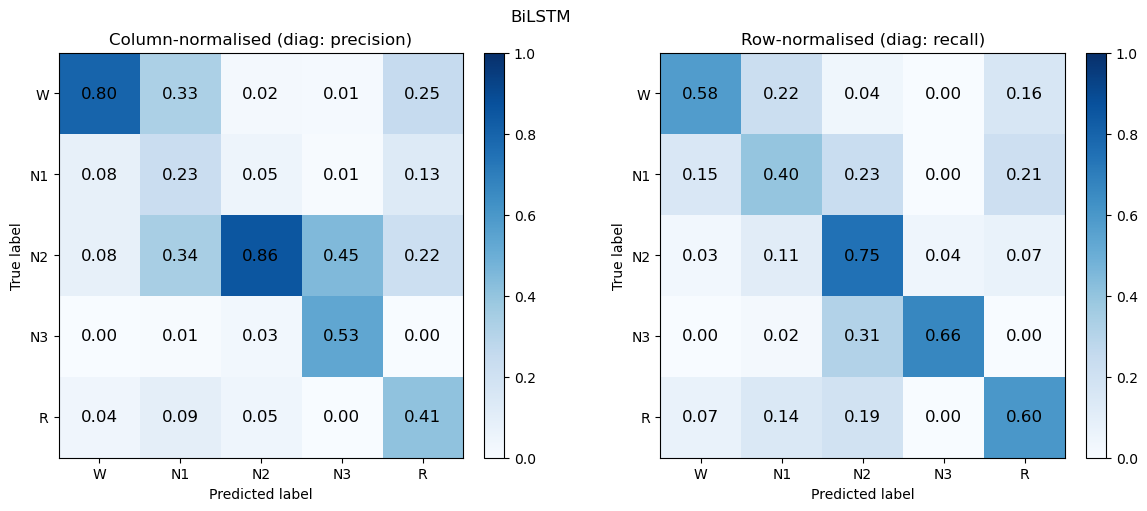

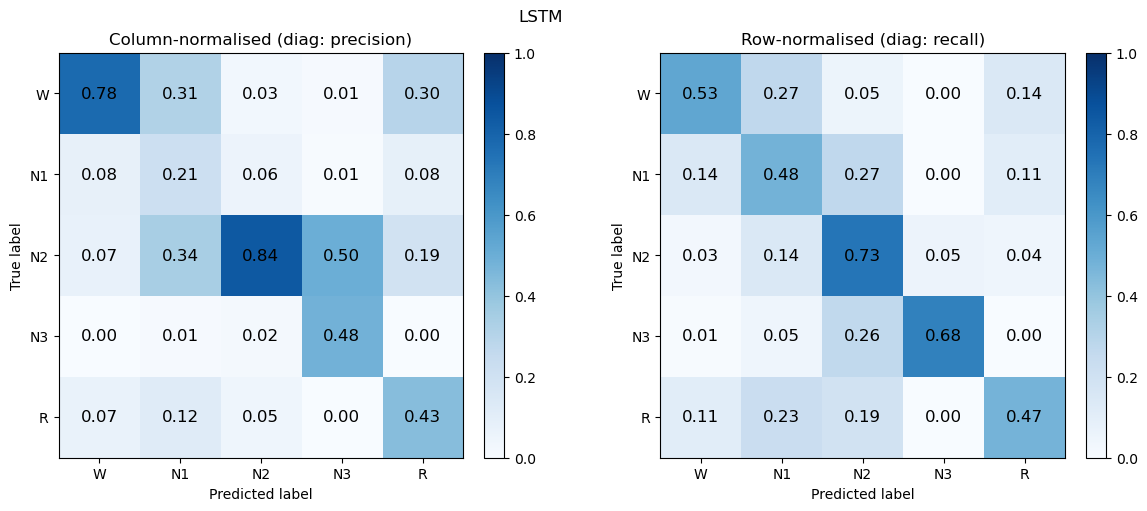

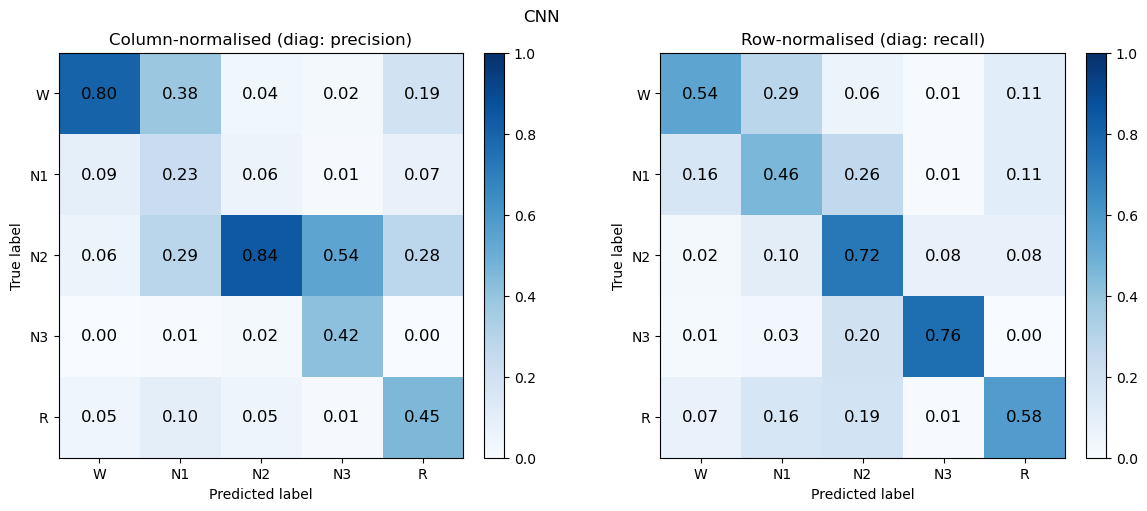

In [61]:
plot_confusion_matrix = sleep_model_utils.plot_confusion_matrix

plot_confusion_matrix(bilstm_eval, STAGE_MAP, title="BiLSTM")
plot_confusion_matrix(lstm_eval,   STAGE_MAP, title="LSTM")
plot_confusion_matrix(cnn_eval,    STAGE_MAP, title="CNN")


# Fit Final Model

In [ ]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
info_trainval = pd.concat([info_train, info_val], ignore_index=True)

def fit_final_model(
    X_train, y_train, info_train,
    *,
    model_class,
    model_kwargs,
    seq_len,
    best_epoch,
    batch_size=64,
    num_classes=5,
    lr=1e-3,
    weight_decay=1e-4,
    subject_col="subject_id",
    block_col="block_id",
    device=None,
):

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, _ = build_loaders(
        X_train, y_train, info_train,
        X_train[:0], y_train[:0], info_train.iloc[:0],   # dummy empty val
        seq_len=seq_len,
        batch_size=batch_size,
        subject_col=subject_col,
        block_col=block_col,
    )

    model = model_class(**model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(best_epoch):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    return model